In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ICIWstyle')
%matplotlib widget

In [2]:
n_dot = np.load("MGA-E-05032025_250ml-min_Analytik_MS_composition.npy")
timestamps = np.load("MGA-E-05032025_250ml-min_Analytik_MS_times.npy")

The switching times are ordered in reverse (ie. the index i) is the time at which the i-th-to last switch happened.

In [3]:
switching_periods = np.array(
    [
        45.18,
        45.28,
        45.12,
        45.11,
        45.20,
        45.21,
        45.25,
        45.08,
        45.08,
        45.00,
    ]
)
switching_times = np.flip(np.cumsum(-switching_periods))
switching_times = np.append(switching_times, 0)
print(switching_times)

[-451.51 -406.51 -361.43 -316.35 -271.1  -225.89 -180.69 -135.58  -90.46
  -45.18    0.  ]


In [4]:
intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
intervals

[(-451.50999999999993, -406.50999999999993),
 (-406.50999999999993, -361.42999999999995),
 (-361.42999999999995, -316.34999999999997),
 (-316.34999999999997, -271.09999999999997),
 (-271.09999999999997, -225.89),
 (-225.89, -180.69),
 (-180.69, -135.58),
 (-135.58, -90.46000000000001),
 (-90.46000000000001, -45.18),
 (-45.18, 0.0)]

In [5]:
time_delta = timestamps - timestamps[-1]
np.savez("MGA-E-05032025_250ml-min_Analytik_MS.npz", n_dot=n_dot, time_delta=time_delta)


t_range = (time_delta.min(), time_delta.max())

In [6]:
import scipy
import scipy.interpolate

interp_H2 = scipy.interpolate.interp1d(time_delta, n_dot[0], kind="linear")
interp_Ar = scipy.interpolate.interp1d(time_delta, n_dot[1], kind="linear")

In [7]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot,
    kind="linear",
    fill_value="extrapolate",
)

In [8]:
t = np.linspace(*t_range, 1000)
n_dot_interp = interp(t)

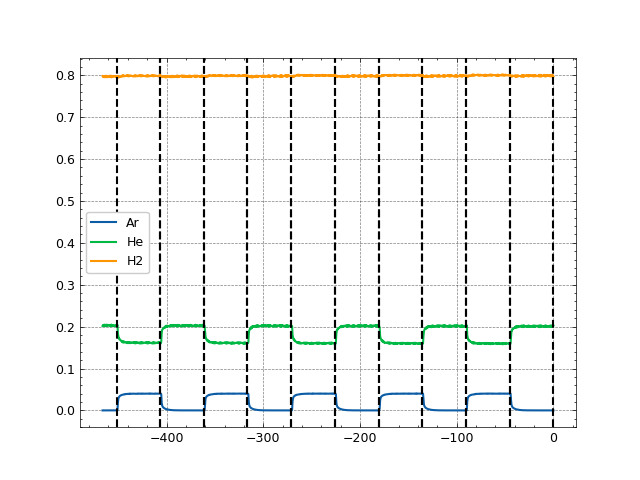

In [ ]:
plt.figure()
plt.plot(t, n_dot_interp[0], label="Ar")



plt.plot(t, n_dot_interp[1], label="He")



plt.plot(t, n_dot_interp[2], label="H2")



for interval in intervals:

    plt.axvline(interval[0], color="black", linestyle="--")

    plt.axvline(interval[1], color="black", linestyle="--")



plt.legend()
plt.show()

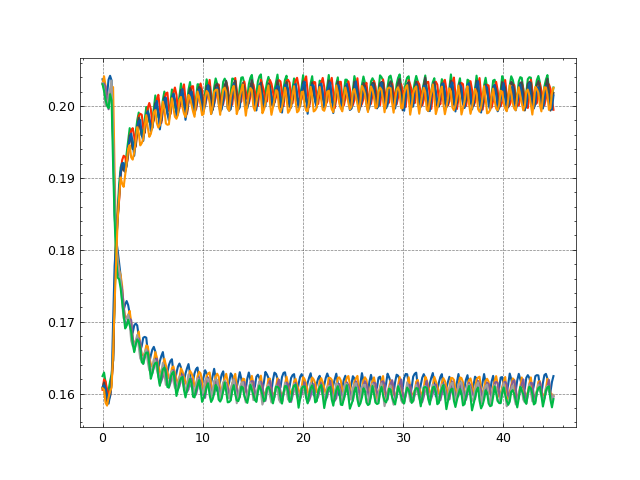

In [ ]:
plt.figure()
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 45, 300)

    n_dot_interp = interp(t)

    plt.plot(t - interval[0], n_dot_interp[1], label=interval)


# plt.legend()
plt.show()